In [73]:
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [74]:
IBM = yf.download(tickers='ibm', period = '5y', interval = '1d', rounding = True)

[*********************100%***********************]  1 of 1 completed


In [75]:
IBM

Price,Close,High,Low,Open,Volume
Ticker,IBM,IBM,IBM,IBM,IBM
Date,,,,,
2021-04-05,106.46,107.06,104.48,104.67,5722980
2021-04-06,105.12,106.23,105.02,106.19,3787566
2021-04-07,105.68,105.68,104.78,104.82,3112896
2021-04-08,105.83,106.23,105.07,105.40,4275211
2021-04-09,106.30,106.31,105.50,105.63,3162999
...,...,...,...,...,...
2026-03-26,241.67,246.67,239.80,240.56,3606800
2026-03-27,236.34,239.44,233.75,238.85,4853700


In [76]:
walmart = yf.download(tickers='wmt', period = '5y', interval = '1d', rounding = True)

[*********************100%***********************]  1 of 1 completed


In [77]:
walmart

Price,Close,High,Low,Open,Volume
Ticker,WMT,WMT,WMT,WMT,WMT
Date,,,,,
2021-04-05,43.52,43.74,42.51,42.67,40043100
2021-04-06,43.72,43.99,43.23,43.42,31044600
2021-04-07,43.63,43.93,43.58,43.79,20361600
2021-04-08,43.60,44.04,43.59,43.83,19095600
2021-04-09,43.62,43.72,43.29,43.58,20676600
...,...,...,...,...,...
2026-03-26,122.18,123.80,121.79,123.61,16442500
2026-03-27,122.89,124.27,121.82,122.03,16543300


In [78]:
IBM = IBM["Close"]
walmart = walmart["Close"]

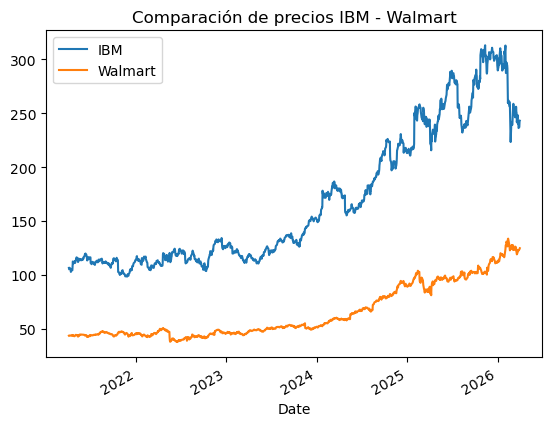

In [79]:
import matplotlib.pyplot as plt

IBM['IBM'].plot()
walmart['WMT'].plot()
plt.legend(["IBM", "Walmart"])
plt.title("Comparación de precios IBM - Walmart")
plt.show()

In [80]:
# índice de correlación entre los precios de IBM - Walmart
correlacion = IBM["IBM"].corr(walmart["WMT"])
print("Correlación entre los precios de IBM y Walmart: ", correlacion)

Correlación entre los precios de IBM y Walmart:  0.9558632444713339


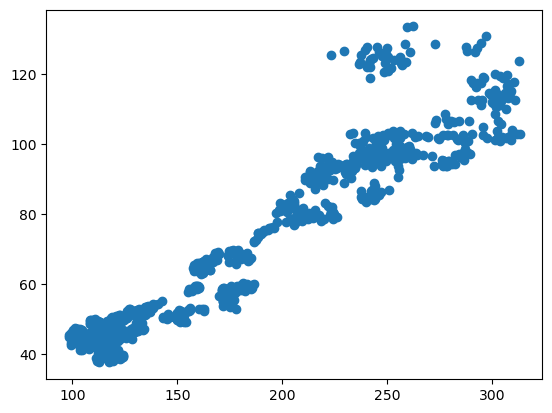

In [81]:
import matplotlib.pyplot as plt
plt.scatter(IBM["IBM"], walmart["WMT"])
plt.show()

## Descomposición de las gráficas de IBM y Walmart

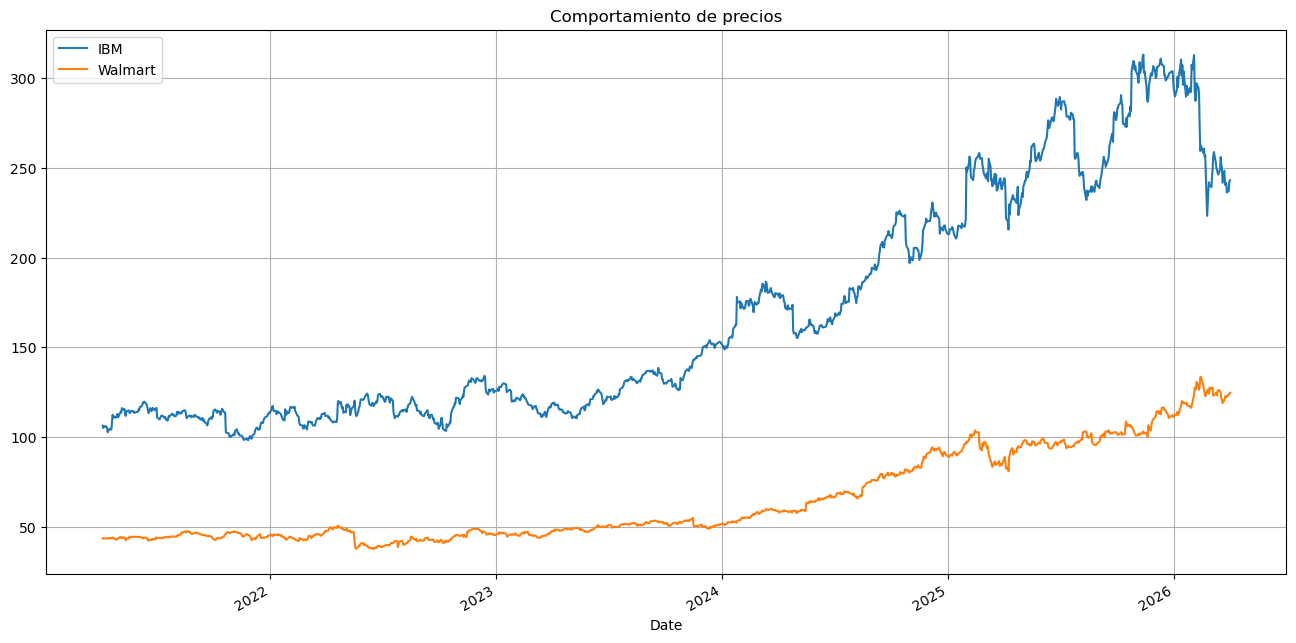

In [86]:
IBM['IBM'].plot(label='IBM', figsize=(16,8))
walmart['WMT'].plot(label='Walmart')
plt.legend()
plt.grid()
plt.title("Comportamiento de precios")
plt.show()

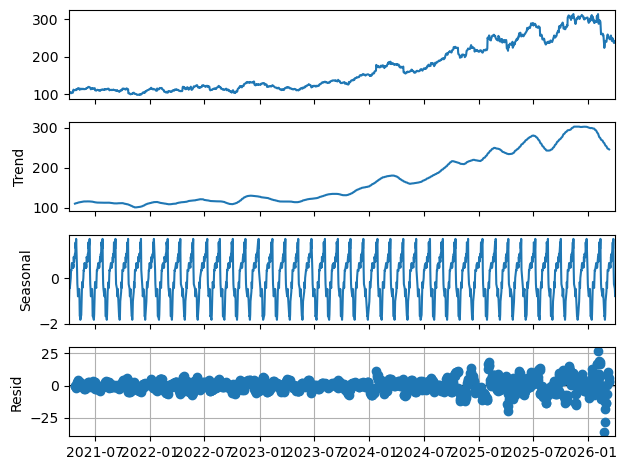

In [87]:
#Descomposición de serie de tiempo para precios en IBM
decomposed_IBM = sm.tsa.seasonal_decompose(IBM, period=30)
figure = decomposed_IBM.plot()
plt.grid()
plt.show()

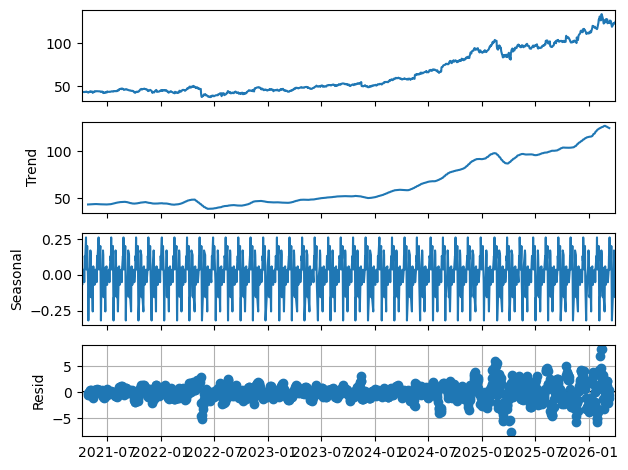

In [88]:
#Descomposición de serie de tiempo para precios en Walmart
decomposed_WMT = sm.tsa.seasonal_decompose(walmart, period=30)
figure = decomposed_WMT.plot()
plt.grid()
plt.show()

## Análisis de Autocorrelación

In [90]:
#Cálculo del índice de autocorrelación para IBM y Walmart
autocorrelacion_IBM = IBM["IBM"].autocorr()
print("El índice de autocorrelación para IBM utilizando intervalos de 1 día es: ", autocorrelacion_IBM)

autocorrelacion_WMT = walmart["WMT"].autocorr()
print("El índice de autocorrelación para Walmart utilizando intervalos de 1 día es: ", autocorrelacion_WMT)

El índice de autocorrelación para IBM utilizando intervalos de 1 día es:  0.9986918903289936
El índice de autocorrelación para Walmart utilizando intervalos de 1 día es:  0.9992479075743823


In [94]:
# Generación de la función de autocorrelación
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

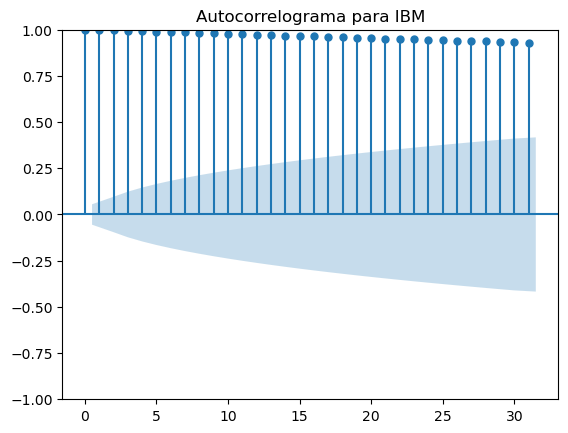

In [93]:
#Gráfica de autocorrelación para IBM
plot_acf(IBM, alpha = 0.05)
plt.title("Autocorrelograma para IBM")
plt.show()

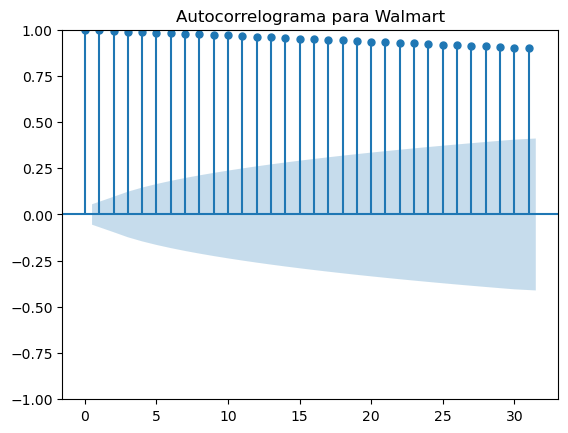

In [95]:
#Gráfica de autocorrelación para Walmart
plot_acf(walmart, alpha = 0.05)
plt.title("Autocorrelograma para Walmart")
plt.show()

In [89]:
#Prueba de Dickey-Fuller
from statsmodels.tsa.stattools import adfuller
import numpy as np

resultado = adfuller(IBM)
print("El valor p de la prueba para IBM es: " + str(resultado[1]))

resultado = adfuller(walmart)
print("El valor p de la prueba para Walmart es: " + str(resultado[1]))

El valor p de la prueba para IBM es: 0.8433651277014811
El valor p de la prueba para Walmart es: 0.9963338573302756


## Análisis gráfico de medias móviles

In [133]:
#Grupos de entrenamiento y prueba
len_train = int(IBM.shape[0] * 0.8)

train_IBM = IBM[0:len_train]
test_IBM = IBM[len_train:]

In [134]:
y_pred_IBM = IBM.copy()
y_pred_IBM = pd.DataFrame(y_pred_IBM)
y_pred_IBM["Pronostico"] = IBM.rolling(30).mean()

In [135]:
# La tabla se muestra desfasada, el promedio de los primeros 30 datos se utiliza la pronosticar la siguiente observación.
# Para solucionar este desfase hacemos lo siguiente:
y_pred_m_IBM = y_pred_IBM.copy()
y_pred_m_IBM.iloc[29,0] = np.nan
for contador in range(30,IBM.shape[0]):
    y_pred_m_IBM.iloc[contador,0] = y_pred_IBM.iloc[contador-1,0]
y_pred_m_IBM.tail()

Ticker,IBM,Pronostico
Date,,
2026-03-26,241.39,248.151000
2026-03-27,241.67,247.378333
2026-03-30,236.34,246.540667
2026-03-31,237.25,246.010000
2026-04-01,242.39,245.421667


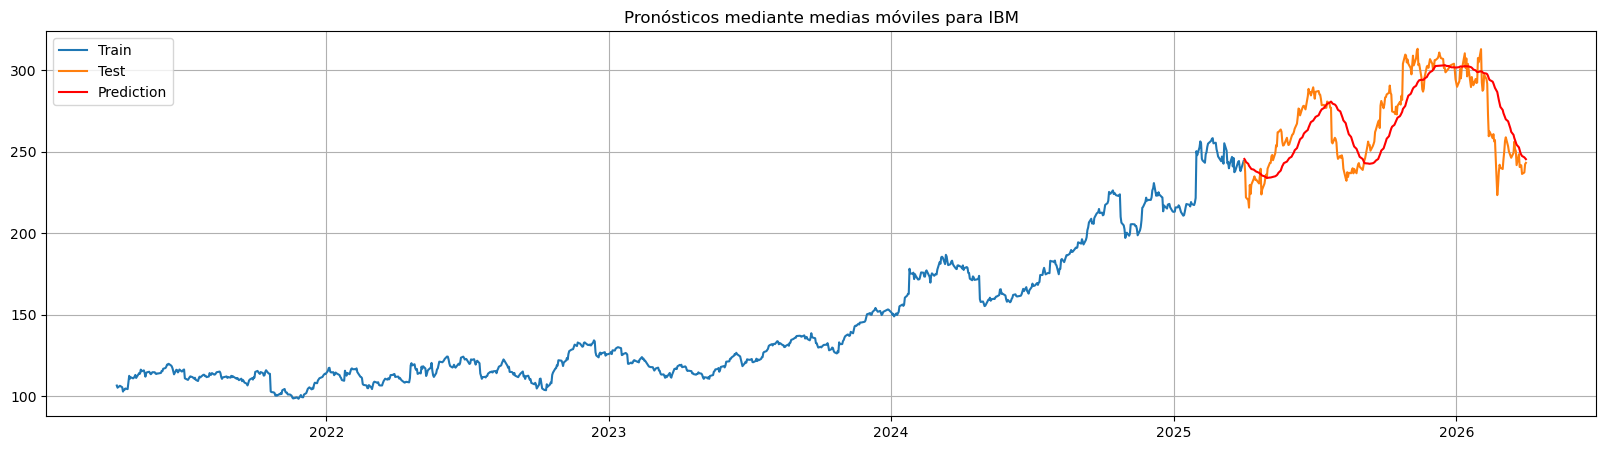

In [136]:
y_pred_m_IBM = pd.DataFrame(y_pred_m_IBM["Pronostico"][len_train:])

plt.figure(figsize = (20,5))
plt.grid()
plt.plot(train_IBM, label = "Train")
plt.plot(test_IBM, label = "Test")
plt.plot(y_pred_m_IBM["Pronostico"], label = "Prediction", color = "red")
plt.legend(loc = "best")
plt.title("Pronósticos mediante medias móviles para IBM")
plt.show()

In [137]:
#Grupos de entrenamiento y prueba
len_train = int(walmart.shape[0] * 0.8)

train_WMT = walmart[0:len_train]
test_WMT = walmart[len_train:]

y_pred_WMT = walmart.copy()
y_pred_WMT = pd.DataFrame(y_pred_WMT)
y_pred_WMT["Pronostico"] = walmart.rolling(30).mean()

y_pred_m_WMT = y_pred_WMT.copy()
y_pred_m_WMT.iloc[29,0] = np.nan
for contador in range(30,walmart.shape[0]):
    y_pred_m_WMT.iloc[contador,0] = y_pred_WMT.iloc[contador-1,0]

y_pred_m_WMT = pd.DataFrame(y_pred_m_WMT["Pronostico"][len_train:])

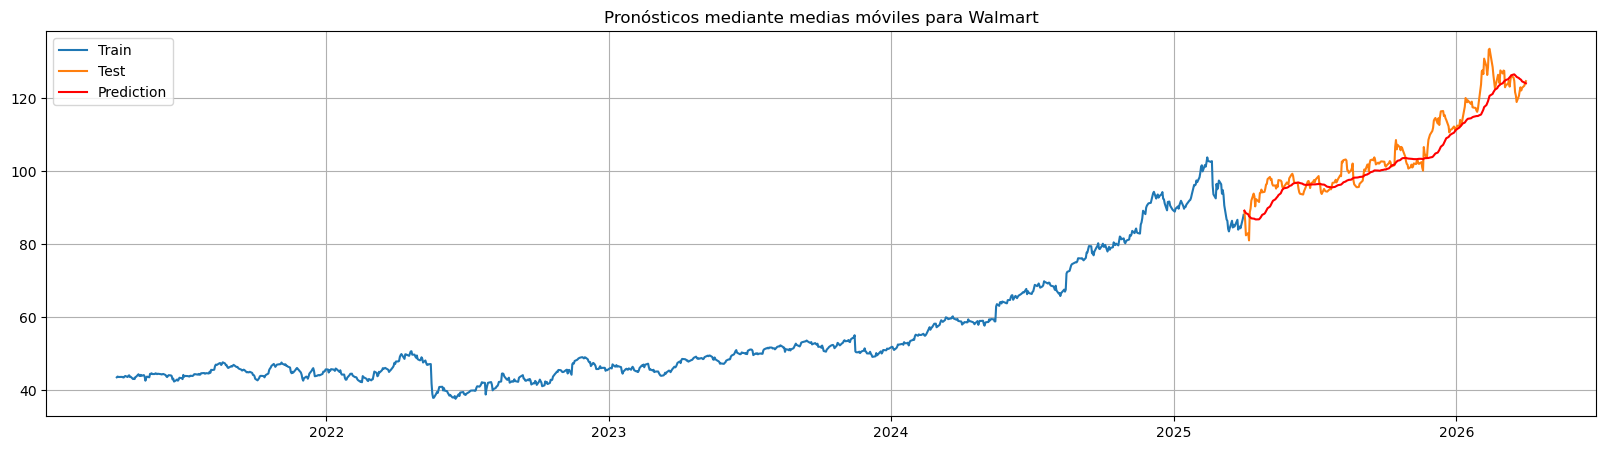

In [138]:
plt.figure(figsize = (20,5))
plt.grid()
plt.plot(train_WMT, label = "Train")
plt.plot(test_WMT, label = "Test")
plt.plot(y_pred_m_WMT["Pronostico"], label = "Prediction", color = "red")
plt.legend(loc = "best")
plt.title("Pronósticos mediante medias móviles para Walmart")
plt.show()

In [131]:
#Pronóstico del día siguiente IBM
print("La predicción para el valor del precio en IBM del siguiente día es: ", y_pred_IBM.tail(1)["Pronostico"].iloc[0])

La predicción para el valor del precio en IBM del siguiente día es:  245.42166666666665


In [132]:
#Pronóstico del día siguiente Walmart
print("La predicción para el valor del precio en Walmart del siguiente día es: ", y_pred_WMT.tail(1)["Pronostico"].iloc[0])

La predicción para el valor del precio en Walmart del siguiente día es:  124.14899999999999


In [139]:
from sklearn.metrics import mean_squared_error

rmse_IBM = np.sqrt(mean_squared_error(test_IBM, y_pred_m_IBM)).round(2)
mape_IBM = np.round(np.mean(np.abs((test_IBM["IBM"] - y_pred_m_IBM["Pronostico"]) / test_IBM["IBM"])) * 100, 2)

rmse_WMT = np.sqrt(mean_squared_error(test_WMT, y_pred_m_WMT)).round(2)
mape_WMT = np.round(np.mean(np.abs((test_WMT["WMT"] - y_pred_m_WMT["Pronostico"]) / test_WMT["WMT"])) * 100, 2)

In [141]:
print("El error en la predicción de IBM es:")
print("RMSE = ", rmse_IBM, "MAPE = ", mape_IBM)
print()
print("El error en la predicción de Walmart es:")
print("RMSE = ", rmse_WMT, "MAPE = ", mape_WMT)

El error en la predicción de IBM es:
RMSE =  17.07 MAPE =  5.18

El error en la predicción de Walmart es:
RMSE =  4.26 MAPE =  3.0
